# This is a notebook for finding/producing compilation errors in AMRs

See https://github.com/ciemss/pyciemss/pull/545

In [12]:
import os
import json
import sympy
import pyciemss

from mira.sources.amr import model_from_url

In [2]:
start_time = 0.0
end_time = 100.0
logging_step_size = 10.0
num_samples = 10

# Models in simulation integration, check observables, initials, etc.

## Grab models

In [24]:
MODEL_PATH = "https://raw.githubusercontent.com/DARPA-ASKEM/simulation-integration/main/data/models/"
DATA_PATH = "https://raw.githubusercontent.com/DARPA-ASKEM/simulation-integration/main/data/datasets/"

model_names = ["LV_goat_chupacabra_regnet.json",
               "LV_rabbits_wolves_model02_regnet.json",
               "LV_rabbits_wolves_model03_regnet.json",
               "LV_rabbits_wolves_regnet.json",
               "LV_sheep_foxes_regnet.json",
               "SEIRD_base_model01_petrinet.json",
               "SEIRD_stockflow.json",
               "SEIRHDS_stockflow.json",
               "SEIRHD_NPI_Type1_petrinet.json",
               "SEIRHD_NPI_Type2_petrinet.json",
               "SEIRHD_base_model01_petrinet.json",
               "SEIRHD_stockflow.json",
               "SEIRHD_with_reinfection01_petrinet.json",
               "SEIR_stockflow.json",
               "SEIR_stockflow_no_uncertainty", ### no json???
               "SIR_stockflow.json",
               "seiarhds.json",
               "sidarthe.json",
               "sir-undef-var-initial.json",
               "sir-undef-var-rate-law.json",
               "sirhd.json" ### ADD S3 Age model
              ]

model1 = os.path.join(MODEL_PATH, "SEIRHD_NPI_Type1_petrinet.json")
model2 = os.path.join(MODEL_PATH, "SEIRHD_NPI_Type2_petrinet.json")
model3 = os.path.join(MODEL_PATH, "SIR_stockflow.json")

dataset1 = os.path.join(DATA_PATH, "SIR_data_case_hosp.csv")
dataset2 = os.path.join(DATA_PATH, "traditional.csv")

In [9]:
result1 = pyciemss.sample(model3, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

1.0*I*S*p_cbeta/p_N
1.0*I/p_tr


,timepoint_id,sample_id,timepoint_unknown,persistent_p_cbeta_param,persistent_p_tr_param,I_state,R_state,S_state
0,0,0,10.0,0.308897,19.750788,13.012599,2.378304,985.609192
1,1,0,20.0,0.308897,19.750788,140.077957,30.485209,830.436157
2,2,0,30.0,0.308897,19.750788,501.983948,195.776703,303.239502
3,3,0,40.0,0.308897,19.750788,480.401154,460.015991,60.583324
4,4,0,50.0,0.308897,19.750788,321.018219,662.328308,17.653812


In [15]:
# template1 = model_from_url(model3)
dir(template1)

['Config',
 '__abstractmethods__',
 '__annotations__',
 '__class__',
 '__class_vars__',
 '__config__',
 '__custom_root_type__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__exclude_fields__',
 '__fields__',
 '__fields_set__',
 '__format__',
 '__ge__',
 '__get_validators__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__include_fields__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__json_encoder__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__post_root_validators__',
 '__pre_root_validators__',
 '__pretty__',
 '__private_attributes__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__repr_args__',
 '__repr_name__',
 '__repr_str__',
 '__rich_repr__',
 '__schema_cache__',
 '__setattr__',
 '__setstate__',
 '__signature__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__try_update_forward_refs__',
 '__validators__',
 '_abc_impl',
 '_calculate_keys',
 '_copy_and_set_values',
 '_decompose_class',
 '_enfo

In [22]:
display(template1.templates)

[ControlledConversion(rate_law=1.0*I*S*p_cbeta/p_N, name='flow1', display_name='NewIncidence', type='ControlledConversion', controller=Concept(name='I', display_name='Infected', description=None, identifiers={}, context={}, units=None), subject=Concept(name='S', display_name='Susceptible', description=None, identifiers={'ido': '0000514'}, context={}, units=None), outcome=Concept(name='I', display_name='Infected', description=None, identifiers={}, context={}, units=None), provenance=[]),
 NaturalConversion(rate_law=1.0*I/p_tr, name='flow2', display_name='NewRecovery', type='NaturalConversion', subject=Concept(name='I', display_name='Infected', description=None, identifiers={}, context={}, units=None), outcome=Concept(name='R', display_name='Recovered', description=None, identifiers={}, context={}, units=None), provenance=[])]

# Lac operon model

In [3]:
lac_petri = "https://raw.githubusercontent.com/gyorilab/mira/scenario5/notebooks/evaluation_2024.03/scenario5/scenario5_petrinet.json"
lac_regnet = "https://raw.githubusercontent.com/gyorilab/mira/scenario5/notebooks/evaluation_2024.03/scenario5/scenario5_regnet.json"

import pyciemss.visuals.plots as plots
import pyciemss.visuals.vega as vega
import pyciemss.visuals.trajectories as trajectories

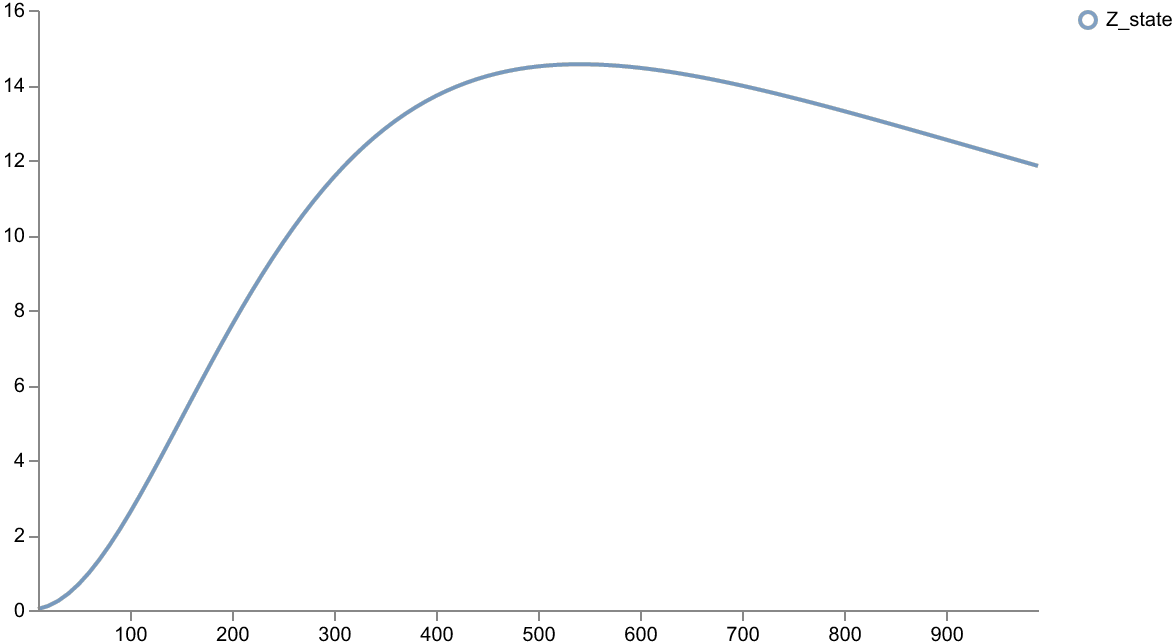

In [6]:
# result1 = pyciemss.sample(lac_petri, end_time, logging_step_size, num_samples, start_time=start_time)
# display(result1['data'].head())

# Plot results for all states
schema = plots.trajectories(result1["data"], keep="Z_state")
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)

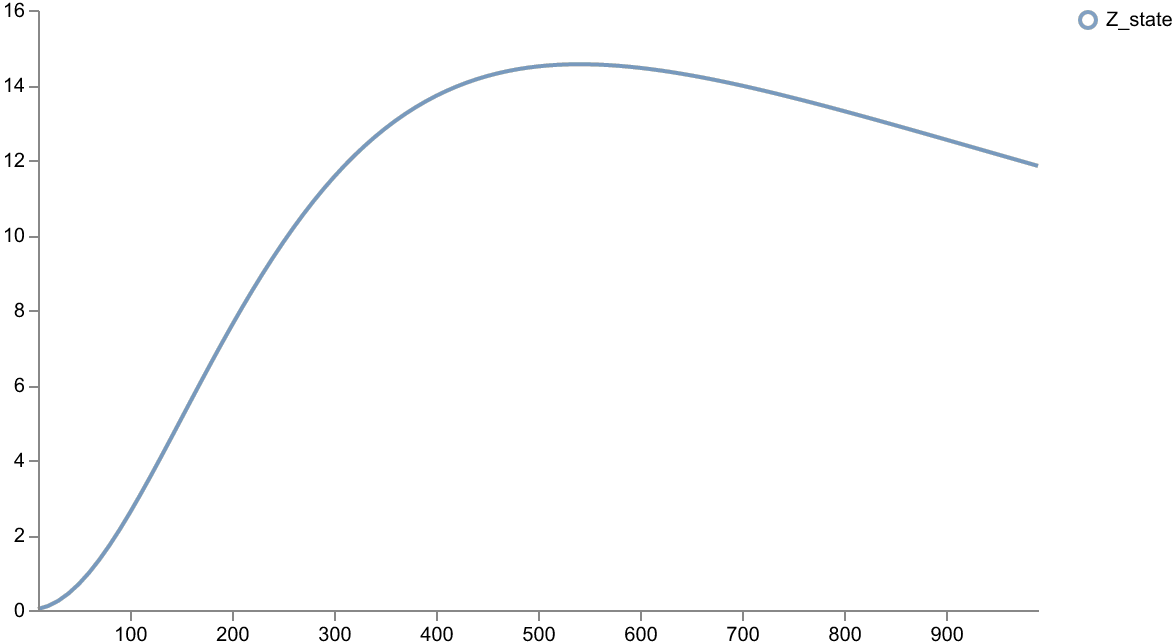

In [7]:
# result1 = pyciemss.sample(lac_regnet, end_time, logging_step_size, num_samples, start_time=start_time)
# display(result1['data'].head())

# Plot results for all states
schema = plots.trajectories(result1["data"], keep="Z_state")
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)

In [8]:
from pyciemss.compiled_dynamics import CompiledDynamics

In [9]:
lac_petri1 = CompiledDynamics.load(lac_petri)
display(lac_petri1)

i*k_1
k_2*r_I
I*Lactose*k_3
I*Lactose*k_3
I*Lactose*k_3
I_Lactose*k_4
I_Lactose*k_4
I_Lactose*k_4
I*Op*k_5
I*Op*k_5
I*Op*k_5
I_Op*k_6
I_Op*k_6
I_Op*k_6
Op*RNAP*k_7
Op*RNAP*k_7
Op*RNAP*k_7
RNAP_Op*k_8
RNAP_Op*k_8
RNAP_Op*k_8
RNAP_Op*k_9
k_10*r_lac
Lactose*Z*k_11
Lactose*Z*k_11
k_12*r_I
I*k_13
k_15*r_lac
Z*k_16


CompiledDynamics(
  (numeric_deriv_func): SymPyModule(expressions=(0, i*k_1 - k_12*r_I, -I*Lactose*k_3 - I*Op*k_5 - I*k_13 + I_Lactose*k_4 + I_Op*k_6 + k_2*r_I, -I*Lactose*k_3 + I_Lactose*k_4 - Lactose*Z*k_11, I*Lactose*k_3 - I_Lactose*k_4, -I*Op*k_5 + I_Op*k_6 - Op*RNAP*k_7 + RNAP_Op*k_8, I*Op*k_5 - I_Op*k_6, -Op*RNAP*k_7 + RNAP_Op*k_8, Op*RNAP*k_7 - RNAP_Op*k_8, RNAP_Op*k_9 - k_15*r_lac, -Lactose*Z*k_11 - Z*k_16 + k_10*r_lac))
  (numeric_initial_state_func): SymPyModule(expressions=(1.00000000000000, 0.0, 50.0000000000000, 500.000000000000, 0.0, 1.00000000000000, 0.0, 100.000000000000, 0.0, 0.0, 0.0))
)

In [10]:
lac_regnet1 = CompiledDynamics.load(lac_regnet)
display(lac_regnet1)

k_12*r_I
I*k_13
I_Lactose*k_14 + I_Lactose*k_4
I_Op*k_6
RNAP_Op*k_8 + RNAP_Op*k_9
k_15*r_lac
Z*k_16
i*k_1
k_2*r_I
I*Lactose*k_3
I*Lactose*k_3
I*Lactose*k_3
I_Lactose*k_4
I_Lactose*k_4
I*Op*k_5
I*Op*k_5
I*Op*k_5
I_Op*k_6
I_Op*k_6
Op*RNAP*k_7
Op*RNAP*k_7
Op*RNAP*k_7
RNAP_Op*k_8
RNAP_Op*k_8
RNAP_Op*k_9
k_10*r_lac
Lactose*Z*k_11
Lactose*Z*k_11


CompiledDynamics(
  (numeric_deriv_func): SymPyModule(expressions=(i*k_1 - k_12*r_I, -I*Lactose*k_3 - I*Op*k_5 - I*k_13 + I_Lactose*k_4 + I_Op*k_6 + k_2*r_I, I*Lactose*k_3 - I_Lactose*k_14 - I_Lactose*k_4, I*Op*k_5 - I_Op*k_6, Op*RNAP*k_7 - RNAP_Op*k_8 - RNAP_Op*k_9, RNAP_Op*k_9 - k_15*r_lac, -Lactose*Z*k_11 - Z*k_16 + k_10*r_lac, 0, -I*Lactose*k_3 + I_Lactose*k_4 - Lactose*Z*k_11, -I*Op*k_5 + I_Op*k_6 - Op*RNAP*k_7 + RNAP_Op*k_8, -Op*RNAP*k_7 + RNAP_Op*k_8))
  (numeric_initial_state_func): SymPyModule(expressions=(0.0, 50.0000000000000, 0.0, 0.0, 0.0, 0.0, 0.0, 1.00000000000000, 500.000000000000, 1.00000000000000, 100.000000000000))
)

In [ ]:
lac_regnet1

In [ ]:
import json
from mira.sources.amr import model_from_url
from mira.modeling.amr.petrinet import template_model_to_petrinet_json
from mira.modeling.amr.regnet import template_model_to_regnet_json

In [ ]:
petri1 = model_from_url(lac_petri)
regnet1 = model_from_url(lac_regnet)

In [ ]:
petri1.templates[0]

In [ ]:
regnet1.templates[0]

In [ ]:
for template in petri1.templates:
    print(template.rate_law)

In [ ]:
petri_json = template_model_to_petrinet_json(petri1)
petri_json

# Save as JSON
with open("petri_to_petri.json", 'w') as fh:
    json.dump(petri_json, fh, indent=1)

In [ ]:
petri_json = template_model_to_petrinet_json(regnet1)
petri_json

# Save as JSON
with open("regnet_to_petri.json", 'w') as fh:
    json.dump(petri_json, fh, indent=1)

# Errors for bad AMRs

In [ ]:
result1 = pyciemss.sample(model1, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

In [ ]:
result1 = pyciemss.sample(model3, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

In [ ]:
# Regnet
result1 = pyciemss.sample(model5, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

In [ ]:
# Petrinet
result1 = pyciemss.sample(model6, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

In [ ]:
result1 = pyciemss.sample(model7, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

# Observables are getting lost somewhere

In [ ]:
# Load petrinet as template model
from mira.sources.amr import model_from_url, model_from_json_file
seird_petri_model = model_from_json_file(model6)
type(seird_petri_model)

In [ ]:
seird_petri_model.observables

In [ ]:
# template_model_to_regnet_json
from mira.modeling.amr.regnet import template_model_to_regnet_json
regnet_version = template_model_to_regnet_json(seird_petri_model)

In [ ]:
import json
with open("seird-regnet.json", "w") as regnet_json:
    json.dump(regnet_version, regnet_json, indent=1)

In [ ]:
model8 = os.path.join(MODEL_PATH, "seird-regnet.json")
seird_regnet_model = model_from_json_file(model8)
seird_regnet_model.initials

In [ ]:
result1 = pyciemss.sample(model8, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

# Underflow error

In [ ]:
# Model to produce underflow error
result1 = pyciemss.sample(model9, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

In [ ]:
result1 = pyciemss.sample(model11, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

In [ ]:
model11